<a href="https://colab.research.google.com/github/yuktiverma43/Data-Science-Projects/blob/main/Bank%20Loan%20Deliquency.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Loan Delinquent Analysis

### Context

DRS bank is facing challenging times. Their NPAs (Non-Performing Assets) have been on a rise recently and a large part of these are due to the loans given to individual customers(borrowers). The Chief Risk Officer of the bank decides to put in a scientifically robust framework for approval of loans to individual customers to minimize the risk of loans converting into NPAs and initiates a project for the data science team at the bank. You, as a senior member of the team, are assigned this project.

### Objective
To identify the criteria to approve loans for an individual customer such that the likelihood of the loan delinquency is minimized

### Key questions to be answered
What are the factors that drive the behavior of loan delinquency?

### Data Description
* ID: Customer ID
* isDelinquent : indicates whether the customer is delinquent or not (1 => Yes, 0 => No)
* term: Loan term in months
* gender: Gender of the borrower
* age: Age of the borrower
* purpose: Purpose of Loan
* home_ownership: Status of borrower's home
* FICO: FICO (i.e. the bureau score) of the borrower

### Domain Information
Transactor – A person who pays his due amount balance full and on time.

Revolver – A person who pays the minimum due amount but keeps revolving his balance and does not pay the full amount.

Delinquent - Delinquency means that you are behind on payments, a person who fails to pay even the minimum due amount.

Defaulter – Once you are delinquent for a certain period your lender will declare you to be in the default stage.

Risk Analytics – A wide domain in the financial and banking industry, basically analyzing the risk of the customer.


### Importing Libraries

In [ ]:
# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Libraries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# To tune model, get different metric scores and split data
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    roc_auc_score,
    plot_confusion_matrix,
)

# To build a logistic regression model
from sklearn.linear_model import LogisticRegression

# To use statistical functions
import scipy.stats as stats

# To oversample and undersample data
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# To suppress the warning
import warnings

warnings.filterwarnings("ignore")

# This will help in making the Python code more structured automatically (good coding practice)
%load_ext nb_black

<IPython.core.display.Javascript object>

### Loading Data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Loan_Delinquent_Dataset.csv")

<IPython.core.display.Javascript object>

In [ ]:
# Checking the number of rows and columns in the data
data.shape

(11548, 8)

<IPython.core.display.Javascript object>

### Data Overview

In [ ]:
# let's create a copy of the data
loan = data.copy()

<IPython.core.display.Javascript object>

In [ ]:
# let's view the first 5 rows of the data
loan.head()

,ID,isDelinquent,term,gender,purpose,home_ownership,age,FICO
0,1,1,36 months,Female,House,Mortgage,>25,300-500
1,2,0,36 months,Female,House,Rent,20-25,>500
2,3,1,36 months,Female,House,Rent,>25,300-500
3,4,1,36 months,Female,Car,Mortgage,>25,300-500
4,5,1,36 months,Female,House,Rent,>25,300-500


<IPython.core.display.Javascript object>

In [ ]:
# let's view the last 5 rows of the data
loan.tail()

,ID,isDelinquent,term,gender,purpose,home_ownership,age,FICO
11543,11544,0,60 months,Male,other,Mortgage,>25,300-500
11544,11545,1,36 months,Male,House,Rent,20-25,300-500
11545,11546,0,36 months,Female,Personal,Mortgage,20-25,>500
11546,11547,1,36 months,Female,House,Rent,20-25,300-500
11547,11548,1,36 months,Male,Personal,Mortgage,20-25,300-500


<IPython.core.display.Javascript object>

In [ ]:
# let's check the data types of the columns in the dataset
loan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11548 entries, 0 to 11547
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   ID              11548 non-null  int64 
 1   isDelinquent    11548 non-null  int64 
 2   term            11548 non-null  object
 3   gender          11548 non-null  object
 4   purpose         11548 non-null  object
 5   home_ownership  11548 non-null  object
 6   age             11548 non-null  object
 7   FICO            11548 non-null  object
dtypes: int64(2), object(6)
memory usage: 721.9+ KB


<IPython.core.display.Javascript object>

## Fixing the data types

* The term, gender, purpose,home_ownership, age and FICO are of object type, will change them to categories.

`converting "objects" to "category" reduces the data space required to store the dataframe`

In [ ]:
loan["term"] = loan["term"].astype("category")
loan["gender"] = loan["gender"].astype("category")
loan["purpose"] = loan["purpose"].astype("category")
loan["home_ownership"] = loan["home_ownership"].astype("category")
loan["age"] = loan["age"].astype("category")
loan["FICO"] = loan["FICO"].astype("category")
loan["isDelinquent"] = loan["isDelinquent"].astype("category")

<IPython.core.display.Javascript object>

In [ ]:
loan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11548 entries, 0 to 11547
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   ID              11548 non-null  int64   
 1   isDelinquent    11548 non-null  category
 2   term            11548 non-null  category
 3   gender          11548 non-null  category
 4   purpose         11548 non-null  category
 5   home_ownership  11548 non-null  category
 6   age             11548 non-null  category
 7   FICO            11548 non-null  category
dtypes: category(7), int64(1)
memory usage: 170.2 KB


<IPython.core.display.Javascript object>

`As seen that the memory usage has decreased from 721.9KB to 249.1KB`

**Observations**
* All the dependent variables except for ID are categorical.


In [ ]:
# let's check for duplicate values in the data
loan.duplicated().sum()

0

<IPython.core.display.Javascript object>

In [ ]:
# let's check for missing values in the data
loan.isnull().sum()

ID                0
isDelinquent      0
term              0
gender            0
purpose           0
home_ownership    0
age               0
FICO              0
dtype: int64

<IPython.core.display.Javascript object>

- There are no missing values in the data

In [ ]:
# let's view the statistical summary of the numerical columns in the data
loan.describe(include="all")

,ID,isDelinquent,term,gender,purpose,home_ownership,age,FICO
count,11548.000000,11548.0,11548,11548,11548,11548,11548,11548
unique,NaN,2.0,2,2,7,3,2,2
top,NaN,1.0,36 months,Male,House,Mortgage,20-25,300-500
freq,NaN,7721.0,10589,6555,6892,5461,5888,6370
mean,5774.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,3333.764789,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,2887.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,5774.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,8661.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<IPython.core.display.Javascript object>

**Observations**   

* Most of the customers are loan delinquent(1)
* Most of the loans are for a 36-month term loan
* More males have applied for loans than females
* Most loan applications are for house loans
* Most customers have either mortgaged their houses
* Mostly customers in the age group 20-25 have applied for a loan
* Most customers have a FICO score between 300 and 500

## Data Pre-Processing

In [ ]:
# checking for unique values in the ID column
loan["ID"].nunique()

11548

<IPython.core.display.Javascript object>

* Since all the values in the ID column are unique we can drop it

In [ ]:
loan.drop(["ID"], axis=1, inplace=True)

<IPython.core.display.Javascript object>

In [ ]:
# checking unique value in purpose
loan["purpose"].unique()

['House', 'Car', 'Other', 'Personal', 'Wedding', 'Medical', 'other']
Categories (7, object): ['House', 'Car', 'Other', 'Personal', 'Wedding', 'Medical', 'other']

<IPython.core.display.Javascript object>

In [ ]:
# We can merge the purpose -  'other' and 'Other' together
loan["purpose"].replace("other", "Other", inplace=True)

<IPython.core.display.Javascript object>

In [ ]:
loan["purpose"].unique()

['House', 'Car', 'Other', 'Personal', 'Wedding', 'Medical']
Categories (6, object): ['House', 'Car', 'Other', 'Personal', 'Wedding', 'Medical']

<IPython.core.display.Javascript object>

## EDA

### Univariate analysis

In [ ]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

<IPython.core.display.Javascript object>

## Observations on isDelinquent

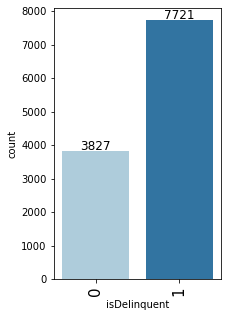

<IPython.core.display.Javascript object>

In [ ]:
labeled_barplot(loan, "isDelinquent")

* 66% of the customers are delinquent

## Observations on term

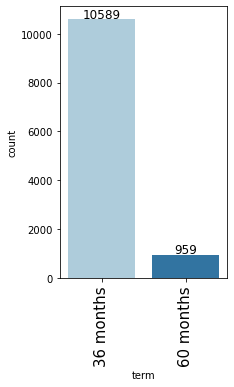

<IPython.core.display.Javascript object>

In [ ]:
labeled_barplot(loan, "term")

* 91.7% of the loans are for a 36-month term.

## Observations on gender

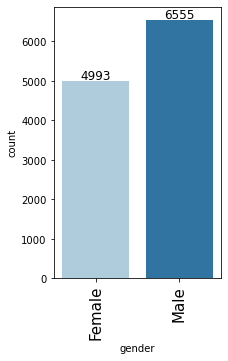

<IPython.core.display.Javascript object>

In [ ]:
labeled_barplot(loan, "gender")

* There are more male applicants (56.8%) than female applicants (43.2%)

## Observations on purpose

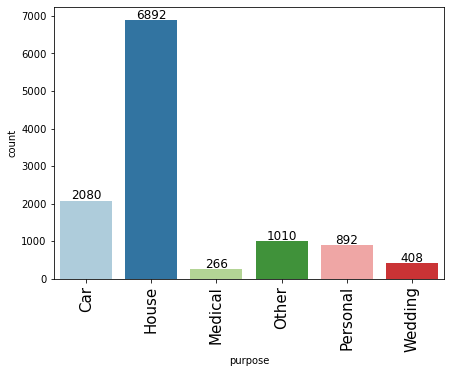

<IPython.core.display.Javascript object>

In [ ]:
labeled_barplot(loan, "purpose")

* Most loan applications are for house loans (59.7%) followed by car loans (18%)
* There are 2 levels named 'other' and 'Other' under the purpose variable. Since there is not any other information about these, will merge these levels.

## Observations on home_ownership

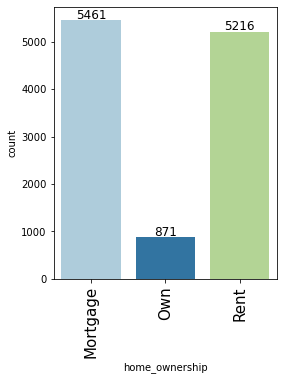

<IPython.core.display.Javascript object>

In [ ]:
labeled_barplot(loan, "home_ownership")

* Very few applicants <10% own their house, Most customers have either mortgaged their houses or live on rent.

## Observations on age

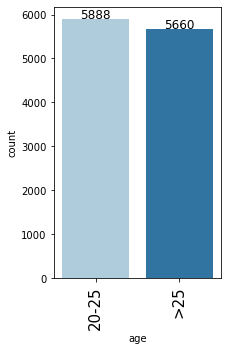

<IPython.core.display.Javascript object>

In [ ]:
labeled_barplot(loan, "age")

* Almost an equal percentage of people aged 20-25 and >25 have applied for the loan.

## Observations on FICO

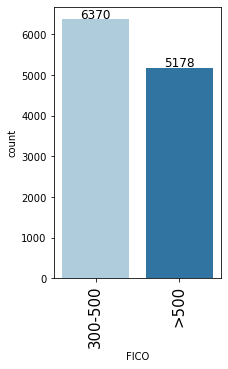

<IPython.core.display.Javascript object>

In [ ]:
labeled_barplot(loan, "FICO")

* Most customers have a FICO score between 300 and 500 (55.2%) followed by a score of greater than 500 (44.8%)

In [ ]:
# function to plot stacked bar chart


def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 1, 5))
    plt.legend(
        loc="lower left",
        frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

<IPython.core.display.Javascript object>

isDelinquent     0     1    All
term                           
All           3827  7721  11548
36 months     3168  7421  10589
60 months      659   300    959
------------------------------------------------------------------------------------------------------------------------


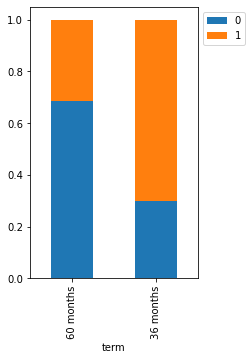

<IPython.core.display.Javascript object>

In [ ]:
stacked_barplot(loan, "term", "isDelinquent")

* Most loan delinquent customers have taken loans for 36 months.

isDelinquent     0     1    All
gender                         
All           3827  7721  11548
Male          1977  4578   6555
Female        1850  3143   4993
------------------------------------------------------------------------------------------------------------------------


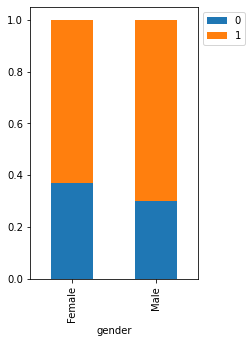

<IPython.core.display.Javascript object>

In [ ]:
stacked_barplot(loan, "gender", "isDelinquent")

* There's not much difference between male and female customers.

isDelinquent     0     1    All
purpose                        
All           3827  7721  11548
House         2272  4620   6892
Car            678  1402   2080
Other          357   653   1010
Personal       274   618    892
Wedding        139   269    408
Medical        107   159    266
------------------------------------------------------------------------------------------------------------------------


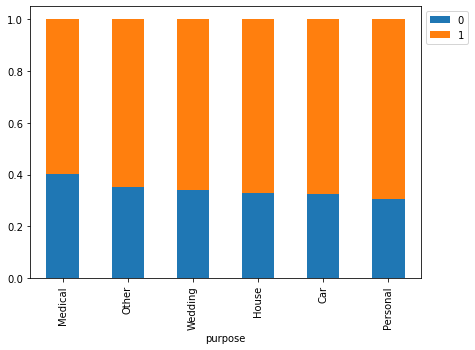

<IPython.core.display.Javascript object>

In [ ]:
stacked_barplot(loan, "purpose", "isDelinquent")

* Most loan delinquent customers are those who have applied for house loans followed by car and personal loans.

isDelinquent       0     1    All
home_ownership                   
All             3827  7721  11548
Mortgage        1831  3630   5461
Rent            1737  3479   5216
Own              259   612    871
------------------------------------------------------------------------------------------------------------------------


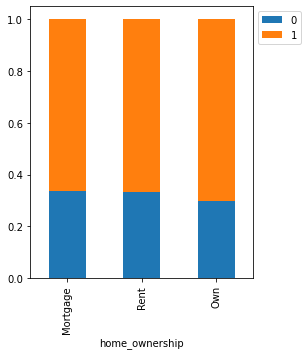

<IPython.core.display.Javascript object>

In [ ]:
stacked_barplot(loan, "home_ownership", "isDelinquent")

* Those customers who have their own house are less delinquent than the ones who live in a rented place or have mortgaged their home.

isDelinquent     0     1    All
age                            
All           3827  7721  11548
>25           1969  3691   5660
20-25         1858  4030   5888
------------------------------------------------------------------------------------------------------------------------


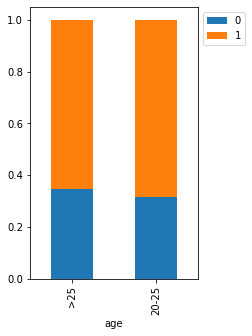

<IPython.core.display.Javascript object>

In [ ]:
stacked_barplot(loan, "age", "isDelinquent")

* Customers between 20-25 years of age are more delinquent.

isDelinquent     0     1    All
FICO                           
All           3827  7721  11548
>500          2886  2292   5178
300-500        941  5429   6370
------------------------------------------------------------------------------------------------------------------------


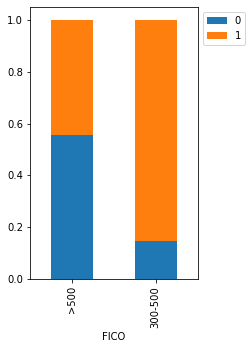

<IPython.core.display.Javascript object>

In [ ]:
stacked_barplot(loan, "FICO", "isDelinquent")

* If the FICO score is >500 the chances of delinquency decrease quite a lot compared to when the FICO score is between 300-500.

### Key Observations
* FICO score and term of loan application appear to be very strong indicators of delinquency.

* Other factors appear to be not very good indicators of delinquency. (We can use chi-square tests to determine statistical significance in the association between two categorical variables).

### We observed that a high FICO score means that the chances of delinquency are lower, let us see if any of the other variables indicate higher a FICO score.

FICO            300-500  >500    All
home_ownership                      
All                6370  5178  11548
Mortgage           2857  2604   5461
Rent               3033  2183   5216
Own                 480   391    871
------------------------------------------------------------------------------------------------------------------------


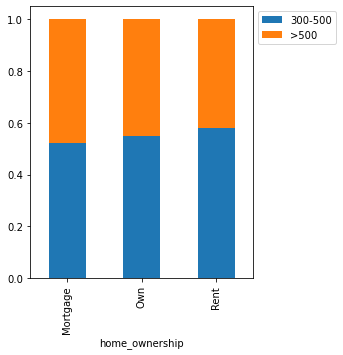

<IPython.core.display.Javascript object>

In [ ]:
stacked_barplot(loan, "home_ownership", "FICO")

FICO   300-500  >500    All
age                        
All       6370  5178  11548
>25       2443  3217   5660
20-25     3927  1961   5888
------------------------------------------------------------------------------------------------------------------------


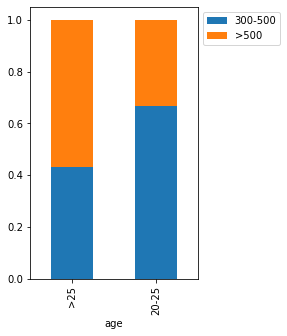

<IPython.core.display.Javascript object>

In [ ]:
stacked_barplot(loan, "age", "FICO")

FICO    300-500  >500    All
gender                      
All        6370  5178  11548
Male       3705  2850   6555
Female     2665  2328   4993
------------------------------------------------------------------------------------------------------------------------


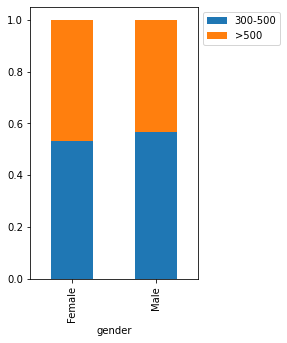

<IPython.core.display.Javascript object>

In [ ]:
stacked_barplot(loan, "gender", "FICO")

## Key Observations

1. Home_ownership and gender seem to have a slight impact on the FICO scores.
2. Age seems to have a much bigger impact on FICO scores.

### Let us check which of these differences are statistically significant.

The Chi-Square test is a statistical method to determine if two categorical variables have a significant correlation between them.
  
**Null Hypothesis -** There is no association between the two variables.      
**Alternate Hypothesis -** There is an association between two variables.

In [ ]:
crosstab = pd.crosstab(
    loan["FICO"], loan["home_ownership"]
)  # Contingency table of region and smoker attributes

Ho = "FICO score has no effect on home ownership"  # Stating the Null Hypothesis
Ha = "FICO score has an effect on home ownership"  # Stating the Alternate Hypothesis

chi, p_value, dof, expected = stats.chi2_contingency(crosstab)

if p_value < 0.05:  # Setting our significance level at 5%
    print(f"{Ha} as the p_value ({p_value.round(3)}) < 0.05")
else:
    print(f"{Ho} as the p_value ({p_value.round(3)}) > 0.05")

FICO score has an effect on home ownership as the p_value (0.0) < 0.05


<IPython.core.display.Javascript object>

In [ ]:
crosstab = pd.crosstab(
    loan["FICO"], loan["gender"]
)  # Contingency table of region and smoker attributes

Ho = "FICO score has no effect on gender"  # Stating the Null Hypothesis
Ha = "FICO score has an effect on gender"  # Stating the Alternate Hypothesis

chi, p_value, dof, expected = stats.chi2_contingency(crosstab)

if p_value < 0.05:  # Setting our significance level at 5%
    print(f"{Ha} as the p_value ({p_value.round(3)}) < 0.05")
else:
    print(f"{Ho} as the p_value ({p_value.round(3)}) > 0.05")

FICO score has an effect on gender as the p_value (0.001) < 0.05


<IPython.core.display.Javascript object>

In [ ]:
crosstab = pd.crosstab(
    loan["FICO"], loan["age"]
)  # Contingency table of region and smoker attributes

Ho = "FICO score has no effect on age"  # Stating the Null Hypothesis
Ha = "FICO score has an effect on age"  # Stating the Alternate Hypothesis

chi, p_value, dof, expected = stats.chi2_contingency(crosstab)

if p_value < 0.05:  # Setting our significance level at 5%
    print(f"{Ha} as the p_value ({p_value.round(3)}) < 0.05")
else:
    print(f"{Ho} as the p_value ({p_value.round(3)}) > 0.05")

FICO score has an effect on age as the p_value (0.0) < 0.05


<IPython.core.display.Javascript object>

## Key Observations

* P-value for all tests < 0.01. Hence, all the differences that we see in the 3 plots are statistically significant.
* There is a correlation between FICO Score and house_ownership. People who have mortgaged their houses have higher FICO scores than people who own the house (peculiar!).
* There is a correlation between FICO Score and gender. More females have >500 FICO scores as compared to Males.
* There is a correlation between FICO Score and age. People >25 years of age have higher FICO scores as compared to people of age 20-25.

### Data Preparation for Modeling

In [ ]:
x = loan.drop(["isDelinquent"], axis=1)
y = loan["isDelinquent"]

<IPython.core.display.Javascript object>

In [ ]:
# encoding the categorical variables
x = pd.get_dummies(x, drop_first=True)
x.head()

,term_60 months,gender_Male,purpose_House,purpose_Medical,purpose_Other,purpose_Personal,purpose_Wedding,home_ownership_Own,home_ownership_Rent,age_>25,FICO_>500
0,0,0,1,0,0,0,0,0,0,1,0
1,0,0,1,0,0,0,0,0,1,0,1
2,0,0,1,0,0,0,0,0,1,1,0
3,0,0,0,0,0,0,0,0,0,1,0
4,0,0,1,0,0,0,0,0,1,1,0


<IPython.core.display.Javascript object>

In [ ]:
# Splitting data into training, validation and test set:
# first we split data into 2 parts, say temporary and test

X_temp, X_test, y_temp, y_test = train_test_split(
    x, y, test_size=0.2, random_state=1, stratify=y
)

# then we split the temporary set into train and validation

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=1, stratify=y_temp
)
print(X_train.shape, X_val.shape, X_test.shape)

(6928, 11) (2310, 11) (2310, 11)


<IPython.core.display.Javascript object>

In [ ]:
print("Number of rows in train data =", X_train.shape[0])
print("Number of rows in validation data =", X_val.shape[0])
print("Number of rows in test data =", X_test.shape[0])

Number of rows in train data = 6928
Number of rows in validation data = 2310
Number of rows in test data = 2310


<IPython.core.display.Javascript object>

## Building the model

### Model evaluation criterion:

**What does a bank want?**
* A bank wants to minimize the loss - it can face 2 types of losses here:
   * Whenever a bank lends money to a customer, they don't return that.
   * A bank doesn't lend money to a customer thinking a customer will default but in reality, the customer won't - opportunity loss.

**Which loss is greater ?**
* Lending to a customer who wouldn't be able to pay back.

**Since we want to reduce loan delinquency we should use Recall as a metric of model evaluation instead of accuracy.**

* Recall - It gives the ratio of True positives to Actual positives, so high Recall implies low false negatives, i.e. low chances of predicting loan-delinquent customers as a non-loan-delinquent customer.

In [ ]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn
def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "Accuracy": acc,
            "Recall": recall,
            "Precision": precision,
            "F1": f1,
        },
        index=[0],
    )

    return df_perf

<IPython.core.display.Javascript object>

In [ ]:
def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

<IPython.core.display.Javascript object>

### Logistic Regression

In [ ]:
lr = LogisticRegression(random_state=1)
lr.fit(X_train, y_train)

LogisticRegression(random_state=1)

<IPython.core.display.Javascript object>

**Let's evaluate the model performance by using KFold and cross_val_score**

- `K-Folds cross-validation` provides dataset indices to split data into train/validation sets. Split dataset into k consecutive stratified folds (without shuffling by default). Each fold is then used once as validation while the k - 1 remaining folds form the training set.

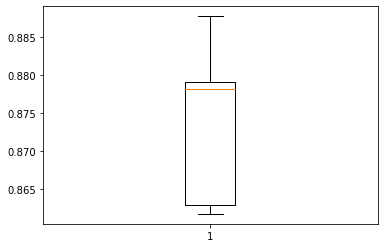

<IPython.core.display.Javascript object>

In [ ]:
scoring = "recall"
kfold = StratifiedKFold(
    n_splits=5, shuffle=True, random_state=1
)  # Setting number of splits equal to 5
cv_result_bfr = cross_val_score(
    estimator=lr, X=X_train, y=y_train, scoring=scoring, cv=kfold
)
# Plotting boxplots for CV scores of model defined above
plt.boxplot(cv_result_bfr)
plt.show()

* Performance on training set varies between 0.86 to 0.87 recall.
* Let's check the performance on validation data.

In [ ]:
# Calculating different metrics on train set
log_reg_model_train_perf = model_performance_classification_sklearn(
    lr, X_train, y_train
)
print("Training performance:")
log_reg_model_train_perf

Training performance:


,Accuracy,Recall,Precision,F1
0,0.782621,0.872409,0.815375,0.842929


<IPython.core.display.Javascript object>

In [ ]:
# Calculating different metrics on validation set
log_reg_model_val_perf = model_performance_classification_sklearn(lr, X_val, y_val)
print("Validation performance:")
log_reg_model_val_perf

Validation performance:


,Accuracy,Recall,Precision,F1
0,0.797403,0.891909,0.820727,0.854839


<IPython.core.display.Javascript object>

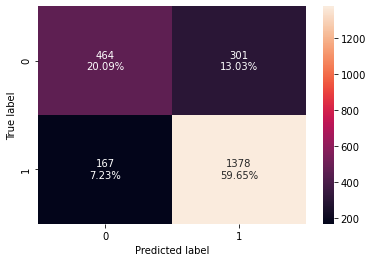

<IPython.core.display.Javascript object>

In [ ]:
# creating confusion matrix
confusion_matrix_sklearn(lr, X_val, y_val)

* Logistic Regression has given a generalized performance on training and validation set.
* Let's try oversampling (increase training data) to see if the model performance can be improved.

### Oversampling train data using SMOTE

In [ ]:
print("Before UpSampling, counts of label 'Yes': {}".format(sum(y_train == 1)))
print("Before UpSampling, counts of label 'No': {} \n".format(sum(y_train == 0)))

sm = SMOTE(
    sampling_strategy=1, k_neighbors=5, random_state=1
)  # Synthetic Minority Over Sampling Technique
X_train_over, y_train_over = sm.fit_resample(X_train, y_train)


print("After UpSampling, counts of label 'Yes': {}".format(sum(y_train_over == 1)))
print("After UpSampling, counts of label 'No': {} \n".format(sum(y_train_over == 0)))


print("After UpSampling, the shape of train_X: {}".format(X_train_over.shape))
print("After UpSampling, the shape of train_y: {} \n".format(y_train_over.shape))

Before UpSampling, counts of label 'Yes': 4632
Before UpSampling, counts of label 'No': 2296 

After UpSampling, counts of label 'Yes': 4632
After UpSampling, counts of label 'No': 4632 

After UpSampling, the shape of train_X: (9264, 11)
After UpSampling, the shape of train_y: (9264,) 



<IPython.core.display.Javascript object>

### Logistic Regression on oversampled data

In [ ]:
log_reg_over = LogisticRegression(random_state=1)

# Training the basic logistic regression model with training set
log_reg_over.fit(X_train_over, y_train_over)

LogisticRegression(random_state=1)

<IPython.core.display.Javascript object>

**Let's evaluate the model performance by using KFold and cross_val_score**

- `K-Folds cross-validation` provides dataset indices to split data into train/validation sets. Split dataset into k consecutive stratified folds (without shuffling by default). Each fold is then used once as validation while the k - 1 remaining folds form the training set.

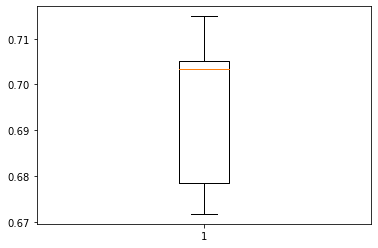

<IPython.core.display.Javascript object>

In [ ]:
scoring = "recall"
kfold = StratifiedKFold(
    n_splits=5, shuffle=True, random_state=1
)  # Setting number of splits equal to 5
cv_result_over = cross_val_score(
    estimator=log_reg_over, X=X_train_over, y=y_train_over, scoring=scoring, cv=kfold
)
# Plotting boxplots for CV scores of model defined above
plt.boxplot(cv_result_over)
plt.show()

* Performance on training set varies between 0.69 to 0.70 recall
* Let's check the performance on Validation set

In [ ]:
# Calculating different metrics on train set
log_reg_over_train_perf = model_performance_classification_sklearn(
    log_reg_over, X_train_over, y_train_over
)
print("Training performance:")
log_reg_over_train_perf

Training performance:


,Accuracy,Recall,Precision,F1
0,0.769754,0.694732,0.817374,0.751079


<IPython.core.display.Javascript object>

In [ ]:
# Calculating different metrics on validation set
log_reg_over_val_perf = model_performance_classification_sklearn(
    log_reg_over, X_val, y_val
)
print("validation performance:")
log_reg_over_val_perf

validation performance:


,Accuracy,Recall,Precision,F1
0,0.760606,0.719094,0.903252,0.800721


<IPython.core.display.Javascript object>

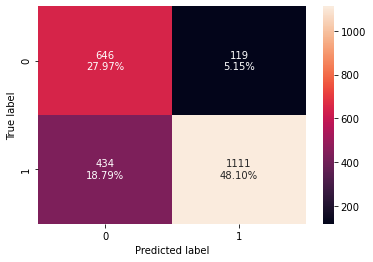

<IPython.core.display.Javascript object>

In [ ]:
# creating confusion matrix
confusion_matrix_sklearn(log_reg_over, X_val, y_val)

* Performance on the training set improved but the model is not able to replicate the same for the validation set.
* Model is overfitting.
* Lets try:

  a) Regularization to see if overfitting can be reduced

  b) Undersampling the train to handle the imbalance between classes and check the model performance.

### Regularization

In [ ]:
# Choose the type of classifier.
lr_estimator = LogisticRegression(random_state=1, solver="saga")

# Grid of parameters to choose from
parameters = {"C": np.arange(0.1, 1.1, 0.1)}

# Run the grid search
grid_obj = GridSearchCV(lr_estimator, parameters, scoring="recall")
grid_obj = grid_obj.fit(X_train_over, y_train_over)

# Set the clf to the best combination of parameters
lr_estimator = grid_obj.best_estimator_

# Fit the best algorithm to the data.
lr_estimator.fit(X_train_over, y_train_over)

LogisticRegression(C=0.1, random_state=1, solver='saga')

<IPython.core.display.Javascript object>

In [ ]:
# Calculating different metrics on train set
log_reg_reg_train_perf = model_performance_classification_sklearn(
    lr_estimator, X_train_over, y_train_over
)
print("Training performance:")
log_reg_reg_train_perf

Training performance:


,Accuracy,Recall,Precision,F1
0,0.739313,0.694732,0.76274,0.727149


<IPython.core.display.Javascript object>

In [ ]:
# Calculating different metrics on validation set
log_reg_reg_val_perf = model_performance_classification_sklearn(
    lr_estimator, X_val, y_val
)
print("Validation performance:")
log_reg_reg_val_perf

Validation performance:


,Accuracy,Recall,Precision,F1
0,0.748918,0.719094,0.88385,0.793005


<IPython.core.display.Javascript object>

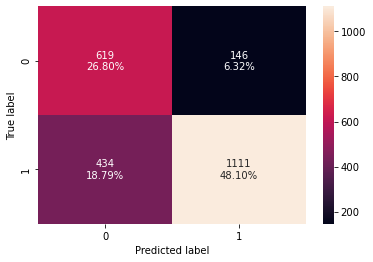

<IPython.core.display.Javascript object>

In [ ]:
# creating confusion matrix
confusion_matrix_sklearn(lr_estimator, X_val, y_val)

* Recall is very good, but similar to previous model

### Undersampling train data using RandomUnderSampler

In [ ]:
rus = RandomUnderSampler(random_state=1)
X_train_un, y_train_un = rus.fit_resample(X_train, y_train)

<IPython.core.display.Javascript object>

In [ ]:
print("Before Under Sampling, counts of label 'Yes': {}".format(sum(y_train == 1)))
print("Before Under Sampling, counts of label 'No': {} \n".format(sum(y_train == 0)))

print("After Under Sampling, counts of label 'Yes': {}".format(sum(y_train_un == 1)))
print("After Under Sampling, counts of label 'No': {} \n".format(sum(y_train_un == 0)))

print("After Under Sampling, the shape of train_X: {}".format(X_train_un.shape))
print("After Under Sampling, the shape of train_y: {} \n".format(y_train_un.shape))

Before Under Sampling, counts of label 'Yes': 4632
Before Under Sampling, counts of label 'No': 2296 

After Under Sampling, counts of label 'Yes': 2296
After Under Sampling, counts of label 'No': 2296 

After Under Sampling, the shape of train_X: (4592, 11)
After Under Sampling, the shape of train_y: (4592,) 



<IPython.core.display.Javascript object>

### Logistic Regression on undersampled data

In [ ]:
log_reg_under = LogisticRegression(random_state=1)
log_reg_under.fit(X_train_un, y_train_un)

LogisticRegression(random_state=1)

<IPython.core.display.Javascript object>

**Let's evaluate the model performance by using KFold and cross_val_score**

- `K-Folds cross-validation` provides dataset indices to split data into train/validation sets. Split dataset into k consecutive stratified folds (without shuffling by default). Each fold is then used once as validation while the k - 1 remaining folds form the training set.

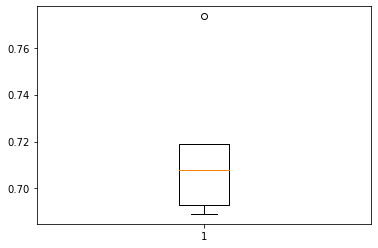

<IPython.core.display.Javascript object>

In [ ]:
scoring = "recall"
kfold = StratifiedKFold(
    n_splits=5, shuffle=True, random_state=1
)  # Setting number of splits equal to 5
cv_result_under = cross_val_score(
    estimator=log_reg_under, X=X_train_un, y=y_train_un, scoring=scoring, cv=kfold
)
# Plotting boxplots for CV scores of model defined above
plt.boxplot(cv_result_under)
plt.show()

* Performance of model on training set varies between 0.70 to 0.76, which is similar to model with oversampled data
* Let's check the performance on the validation set.

In [ ]:
# Calculating different metrics on train set
log_reg_under_train_perf = model_performance_classification_sklearn(
    log_reg_under, X_train_un, y_train_un
)
print("Training performance:")
log_reg_under_train_perf

Training performance:


,Accuracy,Recall,Precision,F1
0,0.768075,0.708624,0.804251,0.753415


<IPython.core.display.Javascript object>

In [ ]:
# Calculating different metrics on validation set
log_reg_under_val_perf = model_performance_classification_sklearn(
    log_reg_under, X_val, y_val
)
print("Validation performance:")
log_reg_under_val_perf

Validation performance:


,Accuracy,Recall,Precision,F1
0,0.769264,0.739806,0.897174,0.810926


<IPython.core.display.Javascript object>

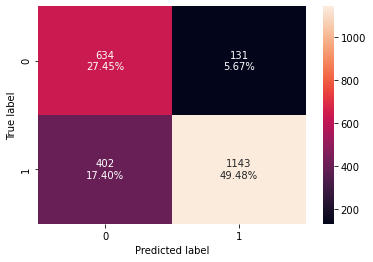

<IPython.core.display.Javascript object>

In [ ]:
# creating confusion matrix
confusion_matrix_sklearn(log_reg_under, X_val, y_val)

* Model has given a generalized performance on training and validation set.
* Model performance has improved using downsampling - Logistic regression is now able to differentiate well between positive and negative classes.

In [ ]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        log_reg_model_train_perf.T,
        log_reg_over_train_perf.T,
        log_reg_reg_train_perf.T,
        log_reg_under_train_perf.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Logistic Regression",
    "Logistic Regression with oversampled data",
    "Regularised Logistic Regression",
    "Logistic Regression with undersampled data",
]
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Logistic Regression,Logistic Regression with oversampled data,Regularised Logistic Regression,Logistic Regression with undersampled data
Accuracy,0.782621,0.769754,0.739313,0.768075
Recall,0.872409,0.694732,0.694732,0.708624
Precision,0.815375,0.817374,0.762740,0.804251
F1,0.842929,0.751079,0.727149,0.753415


<IPython.core.display.Javascript object>

In [ ]:
# Validation performance comparison

models_train_comp_df = pd.concat(
    [
        log_reg_model_val_perf.T,
        log_reg_over_val_perf.T,
        log_reg_reg_val_perf.T,
        log_reg_under_val_perf.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Logistic Regression",
    "Logistic Regression with oversampled data",
    "Regularised Logistic Regression",
    "Logistic Regression with undersampled data",
]
print("Validation performance comparison:")
models_train_comp_df

Validation performance comparison:


,Logistic Regression,Logistic Regression with oversampled data,Regularised Logistic Regression,Logistic Regression with undersampled data
Accuracy,0.797403,0.760606,0.748918,0.769264
Recall,0.891909,0.719094,0.719094,0.739806
Precision,0.820727,0.903252,0.883850,0.897174
F1,0.854839,0.800721,0.793005,0.810926


<IPython.core.display.Javascript object>

* Initial logistic regression without sampling and regularization has given a generalized performance on training and validation set.

### We can see that first model is the best, let's check the performance of test data

In [ ]:
# Calculating different metrics on validation set
log_reg_model_test_perf = model_performance_classification_sklearn(
    log_reg_under, X_test, y_test
)
print("Test performance:")
log_reg_model_test_perf

Test performance:


,Accuracy,Recall,Precision,F1
0,0.765368,0.733808,0.896361,0.80698


<IPython.core.display.Javascript object>

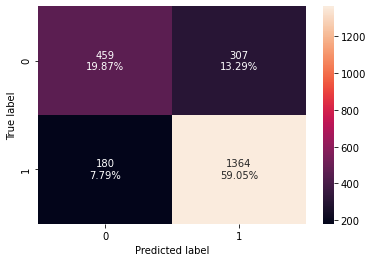

<IPython.core.display.Javascript object>

In [ ]:
# creating confusion matrix
confusion_matrix_sklearn(lr, X_test, y_test)

- Model has given generalised performance on the test set

### Finding the coefficients

In [ ]:
# let us check the coefficients and intercept of the model (lin. and log. reg. sklearn)

coef_df = pd.DataFrame(
    np.append(lr.coef_, lr.intercept_),
    index=X_train.columns.tolist() + ["Intercept"],
    columns=["Coefficients"],
)
coef_df.T

,term_60 months,gender_Male,purpose_House,purpose_Medical,purpose_Other,purpose_Personal,purpose_Wedding,home_ownership_Own,home_ownership_Rent,age_>25,FICO_>500,Intercept
Coefficients,-2.034932,0.793433,0.095047,0.424505,-0.039917,0.18339,0.058346,0.105054,-0.088284,0.565059,-1.981831,1.15384


<IPython.core.display.Javascript object>

### Coefficient interpretations

* Coefficient of gender_Male, purpose_House, purpose_Medical, etc are positive, increase in these will lead to an increase in chances of a person being delinquent
* Coefficient of term_60 months, purpose_Other, home_ownership_Rent, etc increase in these will lead to a decrease in chances of a person not being delinquent

###  Converting coefficients to odds

* The coefficients of the logistic regression model are in terms of log(odd), to find the odds we have to take the exponential of the coefficients.
* Therefore, **odds =  exp(b)**
* The percentage change in odds is given as **odds = (exp(b) - 1) * 100**

* Odds from coefficients

In [ ]:
odds = np.exp(lr.coef_[0])  # converting coefficients to odds
pd.set_option(
    "display.max_columns", None
)  # removing limit from number of columns to display
pd.DataFrame(
    odds, X_train.columns, columns=["odds"]
).T  # adding the odds to a dataframe

,term_60 months,gender_Male,purpose_House,purpose_Medical,purpose_Other,purpose_Personal,purpose_Wedding,home_ownership_Own,home_ownership_Rent,age_>25,FICO_>500
odds,0.130689,2.210974,1.099711,1.528833,0.960869,1.201283,1.060082,1.110771,0.915501,1.759551,0.137817


<IPython.core.display.Javascript object>

* Percentage change in odds

In [ ]:
perc_change_odds = (np.exp(lr.coef_[0]) - 1) * 100  # finding the percentage change
pd.set_option(
    "display.max_columns", None
)  # removing limit from number of columns to display
pd.DataFrame(
    perc_change_odds, X_train.columns, columns=["change_odds%"]
).T  # adding the change_odds% to a dataframe

,term_60 months,gender_Male,purpose_House,purpose_Medical,purpose_Other,purpose_Personal,purpose_Wedding,home_ownership_Own,home_ownership_Rent,age_>25,FICO_>500
change_odds%,-86.931068,121.097447,9.971089,52.883284,-3.913081,20.128295,6.008209,11.077107,-8.449873,75.955084,-86.218331


<IPython.core.display.Javascript object>

### Conclusion

* term: Holding all other features constant a 1 unit change in term_60 months will decrease the odds of a person being delinquent by 0.13 times or a 87% decrease in odds of delinquency

* gender: The odds of a male customer being a delinquent customer is 2.21 times higher than a female or 121% higher than a female customer.

* purpose:
  * The odds of a customer who is seeking a loan for a house being a delinquent customer is 1.09 times higher than for a car or 9.97% higher than a customer who is seeking a loan for a car. (keeping purpose_car as reference).

  * The odds of a customer who is seeking a loan for medical reasons being a delinquent customer is 1.52 times more or 52% higher than a customer who is seeking a loan for a car. (keeping purpose_car as reference).
  
  * The odds of a customer who is seeking a loan for other reasons being a delinquent customer is 0.96% lower or 3.9% lower than a customer who is seeking a loan for a car. (keeping purpose_car as reference).
  
`Interpretation for other attributes can be made similarly.`

* age: Holding all other features constant a 1 unit change in age will increase the odds of a customer above 25 years being a delinquent customer is 1.75 times less than a customer of age group 20-25 or 75.9% higher than the customers in the age group 20-25

* FICO: The odds of a person with a FICO score above 500 being a delinquent customer is 0.13 times less than a customer with a FICO score between 300 to 500 or 86% lower than a customer with a FICO score between 300 to 500.

## Business Insights

* FICO, term and gender are the  important variables in determining if a borrower will get into a delinquent stage
* No borrower shall be given a loan if they are applying for a 36-month term loan and have a FICO score in the range of 300-500.
* Female borrowers with a FICO score greater than 500 should be our target customers.
* Criteria to approve loan according to decision tree model should depend on three main factors - FICO score, duration of loan and gender that is - If the FICO score is less than 500 and the duration of the loan is less than 60 months then the customer will not be able to repay the loans. If the customer has a greater than 500 FICO score and is a female higher chances that they will repay the loans.